In [24]:
# Import libraries
import numpy as np
from matplotlib import pylab as plt
from dopplerkernel import DopplerKernel

# 1. Initialize a DopplerKernel object
For a grid size $n$, the velocity field and weight function will be evaluated on an $n\times n$ grid.

In [15]:
# Create DopplerKernel object
dk = DopplerKernel(grid_size=100)

# 2. Create a velocity field 
**Parameters (see Appendix A in Wardenier et al. 2025):**

- Orbital phase $\phi \in [0,1)$, with $\phi = 0$ for transit and $\phi = 0.5$ for eclipse
- Rotational velocity at the equator $v_{\text{rot}}$ in km/s
- Source-to-sink flow speed $v_{\text{wind}}$ in km/s
- Sink longitude $\varphi_{\text{sink}}$ in degrees
- Jet speed at equator $v_{\text{jet}}$ in km/s
- Jet spatial width $\sigma_{\text{jet}}$ in units of $R_{\text{p}}$ 

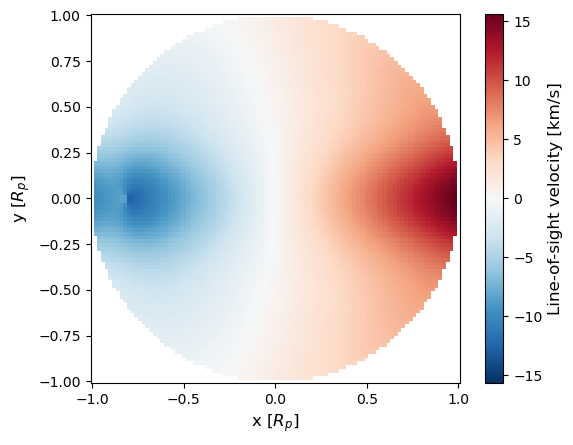

In [17]:
# Calculate the line-of-sight velocity field
dk.make_velocity_field(orbital_phase=0.35, v_rot=5., v_wind=3., sink_longitude=160., v_jet=8., sigma_jet=0.2)

# Plot the line-of-sight velocity field
dk.plot_velocity_map()

# 3. Create a weight mask 
**Parameters (see Appendix B in Wardenier et al. 2025):**

- Orbital phase $\phi \in [0,1)$, with $\phi = 0$ for transit and $\phi = 0.5$ for eclipse
- Weight $w_0$ of the disk center relative to the limb (the limb always has weight 1)
- nightside_zero: if True, the nightside will have zero weight

N.B. The mask will always be normalized (no matter the value of $w_0$). 

If `advanced_mask` is True, the function will consider three more parameters that are otherwise ignored:
- peak_shift_longitude $\varphi_{\text{peak}}$: shift of the weight peak relative to the substellar point (in degrees longitude)
- peak_shift_latitude $\theta_{\text{peak}}$: shift of the weight peak(s) relative to the substellar point (in degrees latitude)
- peak_dropoff $f_{\text{d}}$: strength of the peak dropoff towards the terminator ($f_{\text{d}} = 1$ for maximum dropoff and $f_{\text{d}} = 0$ for uniform weights) 

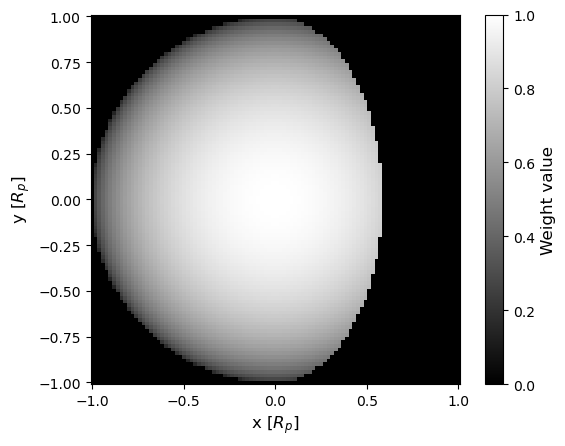

In [19]:
# Calculate the weight maks
dk.make_weight_mask(orbital_phase=0.35, w_0=10., peak_shift_longitude=0., peak_shift_latitude=80., 
                        peak_dropoff=1., nightside_zero=True, advanced_mask=False)

# Plot the weight mask
dk.plot_weight_mask()

# 4. Calculate the broadening kernel
Calculate the kernel based on the previously created line-of-sight velocity field and weight mask. Setting `calculate_x_y_arrays = True` will store the x and y values of the plot below in `dk.kernel_x_values` and `dk.kernel_y_values`.

N.B. Note that `calculate_doppler_kernel()` always assumes the most recently computed line-of-sight velocity field and weight mask. Just make sure these were created at the same orbital phase.

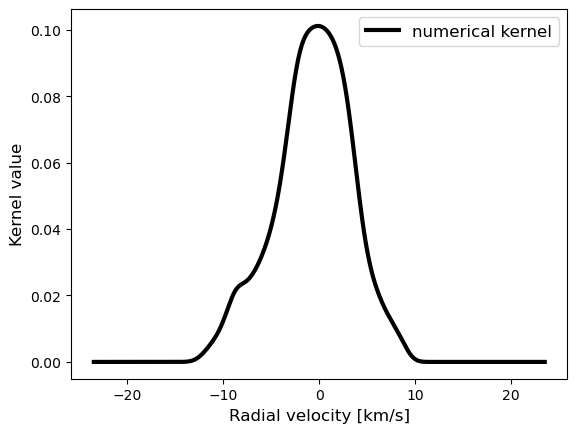

In [27]:
# Calculate the broadening kernel
dk.calculate_doppler_kernel(calculate_x_y_arrays=False)

# Plot the broadening kernel
dk.plot_doppler_kernel()

# 5. Perform a convolution with a spectrum
In this example, we convolve a template containing $\ce{CO}$ and $\ce{H2O}$ lines with the above broadening kernel. The `convolve_with_spectrum()` function simply takes the wavelength and the flux as inputs.

number of wavelength points: 46040


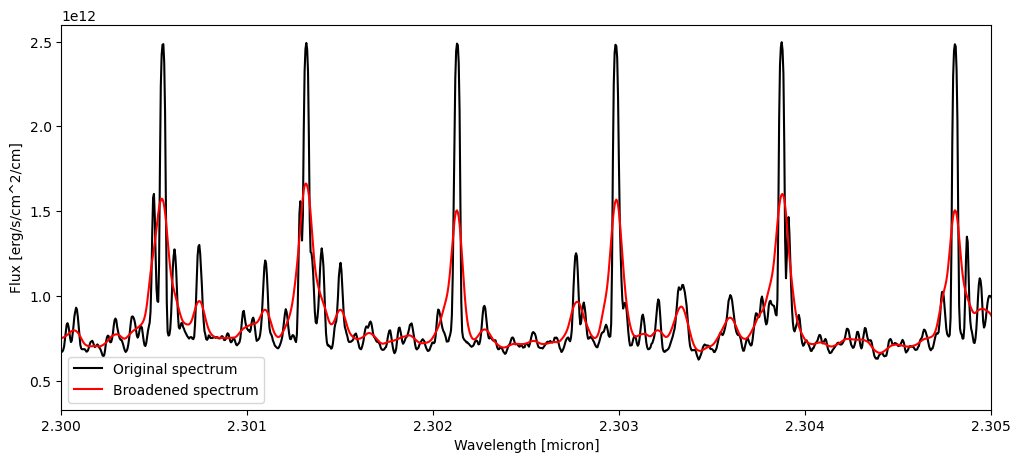

In [70]:
# Load a template spectrum
data = np.genfromtxt('template_spectrum.txt')
wlen = data[:,0] # in micron
flux = data[:,1] # in erg/s/cm^2/cm

print('number of wavelength points:', len(wlen))

# Convolve the spectrum with the previously xreated broadening kernel
broadened_flux = dk.convolve_with_spectrum(wlen, flux)

# Plot the result
plt.figure(figsize=(12,5))
plt.plot(wlen, flux, color='k', label='Original spectrum')
plt.plot(wlen, broadened_flux, color='r', label='Broadened spectrum')
plt.xlabel('Wavelength [micron]')
plt.ylabel('Flux [erg/s/cm^2/cm]')
plt.legend()
plt.xlim([2.30,2.305]) # Zoom in on a small part of the spectrum to see the line shapes
plt.show()